In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('SuperMarket Analysis.csv')
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## Data Overview

In [2]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
count,1000,1000,1000,1000,1000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000
unique,1000,3,3,2,2,6,NaN,NaN,NaN,NaN,89,506,3,NaN,NaN,NaN,NaN
top,750-67-8428,Alex,Yangon,Member,Female,Fashion accessories,NaN,NaN,NaN,NaN,2/7/2019,7:48:00 PM,Ewallet,NaN,NaN,NaN,NaN
freq,1,340,340,565,571,178,NaN,NaN,NaN,NaN,20,7,345,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,55.672130,5.510000,15.379369,322.966749,NaN,NaN,NaN,307.58738,4.761905e+00,15.379369,6.97270
std,NaN,NaN,NaN,NaN,NaN,NaN,26.494628,2.923431,11.708825,245.885335,NaN,NaN,NaN,234.17651,6.131498e-14,11.708825,1.71858
min,NaN,NaN,NaN,NaN,NaN,NaN,10.080000,1.000000,0.508500,10.678500,NaN,NaN,NaN,10.17000,4.761905e+00,0.508500,4.00000
25%,NaN,NaN,NaN,NaN,NaN,NaN,32.875000,3.000000,5.924875,124.422375,NaN,NaN,NaN,118.49750,4.761905e+00,5.924875,5.50000
50%,NaN,NaN,NaN,NaN,NaN,NaN,55.230000,5.000000,12.088000,253.848000,NaN,NaN,NaN,241.76000,4.761905e+00,12.088000,7.00000
75%,NaN,NaN,NaN,NaN,NaN,NaN,77.935000,8.000000,22.445250,471.350250,NaN,NaN,NaN,448.90500,4.761905e+00,22.445250,8.50000


##  Data Preprocessing

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Hour'] = pd.to_datetime(df['Time']).dt.hour

df.isnull().sum()

/var/folders/cf/lx7fhwzs5nb31n8yc22rjrj00000gn/T/ipykernel_15136/3929064882.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour'] = pd.to_datetime(df['Time']).dt.hour


Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Hour                       0
dtype: int64

##  Best-Selling Products

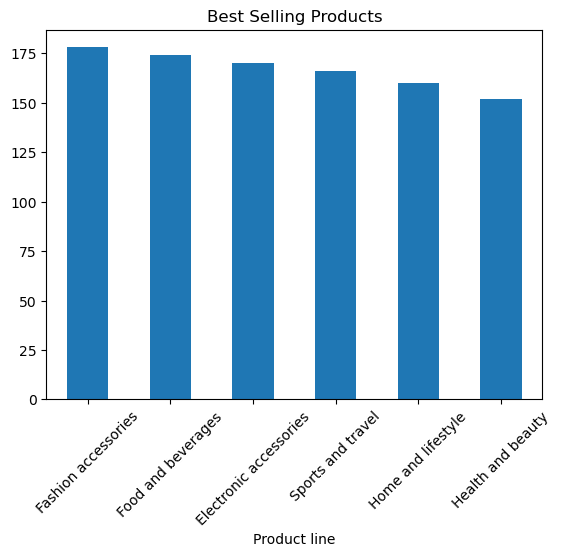

In [4]:
product_sales = df['Product line'].value_counts()
product_sales

product_sales.plot(kind='bar')
plt.title('Best Selling Products')
plt.xticks(rotation=45)
plt.show()

##  Time-Based Sales Trends

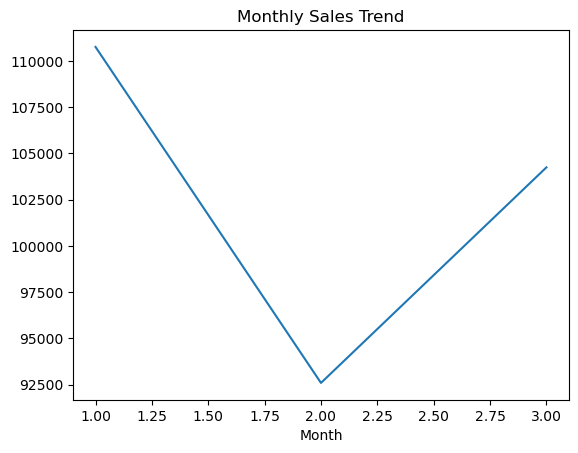

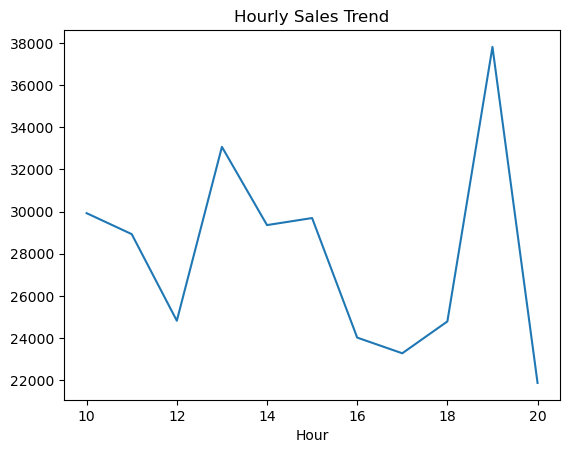

In [9]:
df['Total'] = df['Unit price'] * df['Quantity']
monthly_sales = df.groupby('Month')['Total'].sum()
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.show()

hourly_sales = df.groupby('Hour')['Total'].sum()
hourly_sales.plot()
plt.title('Hourly Sales Trend')
plt.show()

##  Association Rule Mining (Apriori)

In [10]:
%pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.1 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 4.6 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: matplotlib 3.10.60/3 [scikit-learn]
    Uninstalling matplotlib-3.10.6:━━━━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.6━━━━━━━━━━━━━━━━━━ 1/3 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mlxtend]m1/3 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [13]:
from mlxtend.frequent_patterns import apriori, association_rules

# Create basket
basket = df.groupby(['Invoice ID', 'Product line'])['Quantity'].sum().unstack().fillna(0)

# Convert to boolean (IMPORTANT FIX)
basket = basket > 0

# Apply Apriori
frequent_items = apriori(basket, min_support=0.05, use_colnames=True)

# Generate rules
rules = association_rules(frequent_items, metric='lift', min_threshold=1)

rules.sort_values('lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


##  Customer Segmentation (K-Means Clustering)

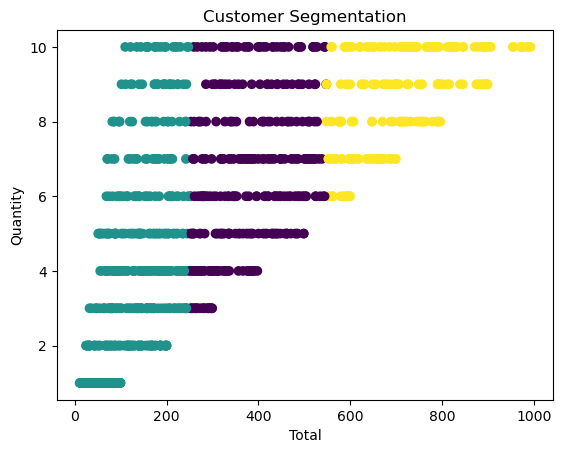

In [14]:
from sklearn.cluster import KMeans

X = df[['Total', 'Quantity']]

kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)

plt.scatter(df['Total'], df['Quantity'], c=df['Cluster'])
plt.xlabel('Total')
plt.ylabel('Quantity')
plt.title('Customer Segmentation')
plt.show()

## Cluster Analysis 

In [15]:

cluster_summary = df.groupby('Cluster')[['Total', 'Quantity']].mean()
print("Cluster Summary:\n")
print(cluster_summary)

Cluster Summary:

              Total  Quantity
Cluster                      
0        378.822730  6.511111
1        124.584297  3.830078
2        719.485896  8.658960


# Labelling the clusters manually based on the spendings 

In [ ]:


def label_customer(row):
    if row['Total'] > df['Total'].mean():
        return "High Value"
    elif row['Total'] > df['Total'].median():
        return "Medium Value"
    else:
        return "Low Value"

df['Customer_Type'] = df.apply(label_customer, axis=1)

print(df[['Total', 'Quantity', 'Customer_Type']].head())

    Total  Quantity Customer_Type
0  522.83         7    High Value
1   76.40         5     Low Value
2  324.31         7    High Value
3  465.76         8    High Value
4  604.17         7    High Value


## Peak Time Analysis

In [ ]:


peak_hour = df.groupby('Hour')['Total'].sum().idxmax()
peak_month = df.groupby('Month')['Total'].sum().idxmax()

print(f"Peak Sales Hour: {peak_hour}:00")
print(f"Peak Sales Month: {peak_month}")

Peak Sales Hour: 19:00
Peak Sales Month: 1


## Best Selling Product

In [ ]:


best_products = df['Product line'].value_counts()

print("Best Selling Products:\n")
print(best_products)

Best Selling Products:

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: count, dtype: int64


## Revenue Analysis 

In [ ]:


total_revenue = df['Total'].sum()
avg_transaction = df['Total'].mean()

print(f"Total Revenue: {round(total_revenue,2)}")
print(f"Average Transaction Value: {round(avg_transaction,2)}")

Total Revenue: 307587.38
Average Transaction Value: 307.59


## Business Insights 

In [23]:


print("\n📊 BUSINESS INSIGHTS:\n")

# Top Product
top_product = df['Product line'].value_counts().idxmax()
print(f"✔ Best Selling Category: {top_product}")

# Peak Time
print(f"✔ Peak Sales Hour: {peak_hour}:00")

# Revenue
print(f"✔ Total Revenue Generated: {round(total_revenue,2)}")

# Association Rule
if not rules.empty:
    top_rule = rules.sort_values('lift', ascending=False).iloc[0]
    print(f"✔ Customers buying {list(top_rule['antecedents'])} also buy {list(top_rule['consequents'])}")

# Clustering Insight
print("✔ High value customers contribute more revenue → target them with loyalty programs")

print("\n📌 RECOMMENDATIONS:")
print("👉 Increase stock of best-selling products")
print("👉 Use combo offers based on association rules")
print("👉 Focus marketing during peak hours")
print("👉 Provide discounts to low-value customers")


📊 BUSINESS INSIGHTS:

✔ Best Selling Category: Fashion accessories
✔ Peak Sales Hour: 19:00
✔ Total Revenue Generated: 307587.38
✔ High value customers contribute more revenue → target them with loyalty programs

📌 RECOMMENDATIONS:
👉 Increase stock of best-selling products
👉 Use combo offers based on association rules
👉 Focus marketing during peak hours
👉 Provide discounts to low-value customers
